In [39]:
# ================================
#Upload dataset locally
# ================================
from google.colab import files
uploaded = files.upload()

Saving cs-training.csv to cs-training (1).csv


In [40]:
# ================================
#Importing necessary libraries
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [41]:
# ===========================================================
#Loading dataset into DataFrame and Displaying several values
# ===========================================================
df = pd.read_csv("cs-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [42]:
# ================================
#Removing unnecessary columns
# ================================
df = df.drop(columns=["Unnamed: 0"])

In [43]:
# ================================
#Describing Dataset
# ================================
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [44]:
# ================================
#Checking Null Values
# ================================
df.isnull().sum()

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


In [45]:
# ================================
#Filling the Null values
# ================================
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

In [46]:
# ================================
#Again Checking for Null  Values
# ================================
df.isnull().sum()

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


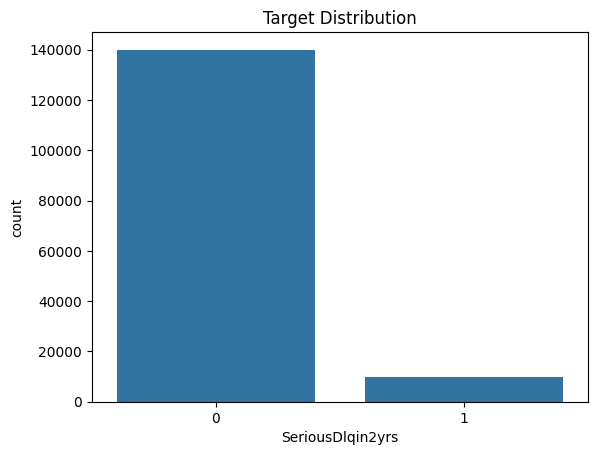

In [47]:
# =============================================
#Plotting Values for our visual  Understanding
# =============================================
sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title("Target Distribution")
plt.show()

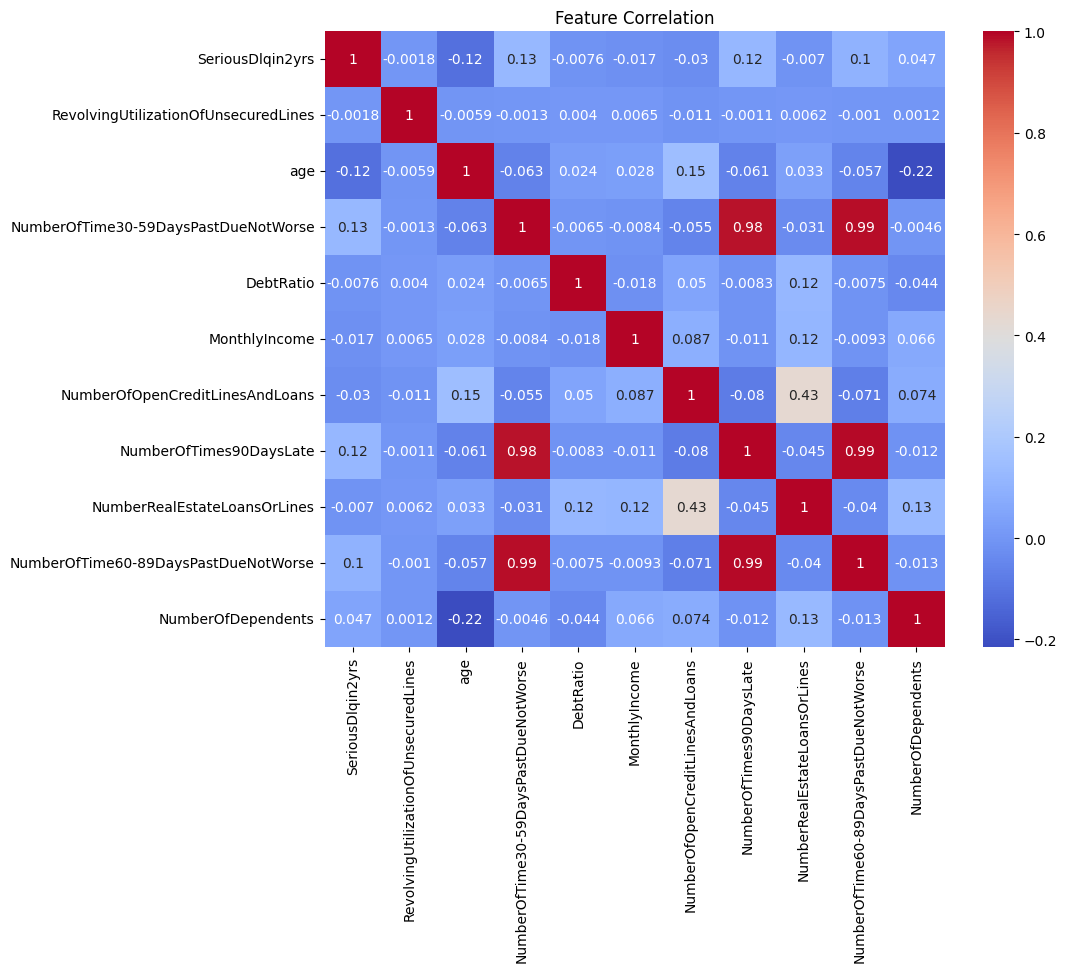

In [48]:
# ================================
#Correlation Heat-Map for our dataset
# ================================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [49]:
# ================================
#Feature Engineering
# ================================
df['income_debt_ratio'] = df['MonthlyIncome']/(df['DebtRatio']+1)

df['credit_utilization'] = df['RevolvingUtilizationOfUnsecuredLines']/(df['NumberOfOpenCreditLinesAndLoans']+1)

In [50]:
# ================================
#Feature and Target Seperation
# ================================
X = df.drop("SeriousDlqin2yrs", axis=1)

y = df["SeriousDlqin2yrs"]

In [51]:
# ================================
#Scaling Values
# ================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [52]:
# ====================================
#Splitting into train and testing data
# ====================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
# from sklearn.model_selection import train_test_split

# # X = features, y = target
# X = df.drop('SeriousDlqin2yrs', axis=1)
# y = df['SeriousDlqin2yrs']

# # Train Test Split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # Confirmation prints
# print("Training Feature Shape:", X_train.shape)
# print("Testing Feature Shape:", X_test.shape)
# print("Training Labels Shape:", y_train.shape)
# print("Testing Labels Shape:", y_test.shape)

In [97]:
# ================================
  #Handling class Imblance
# ================================

sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)

In [55]:
# ================================
  #Logistic Regression
# ================================

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7551666666666667


In [56]:
# ==================================
#Caluculating Accuracy Scores for LR
# ==================================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_pred = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, lr_pred)*100,2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression
Accuracy: 75.52 %

Confusion Matrix:
[[21375  6669]
 [  676  1280]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.85     28044
           1       0.16      0.65      0.26      1956

    accuracy                           0.76     30000
   macro avg       0.57      0.71      0.56     30000
weighted avg       0.92      0.76      0.81     30000



In [57]:
# ================================
#Decision Tree
# ================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(
    max_depth=2,
    min_samples_split=200,
    min_samples_leaf=100,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6000333333333333


In [58]:
# ================================
#Caluculating Accuracy Scores for DT
# ================================

dt_pred = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", round(accuracy_score(y_test, dt_pred)*100,2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree
Accuracy: 60.0 %

Confusion Matrix:
[[16284 11760]
 [  239  1717]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.58      0.73     28044
           1       0.13      0.88      0.22      1956

    accuracy                           0.60     30000
   macro avg       0.56      0.73      0.48     30000
weighted avg       0.93      0.60      0.70     30000



In [59]:
# ================================
#Random Forest
# ================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=5,
    max_depth=2,
    max_features=2,
    min_samples_split=300,
    min_samples_leaf=150,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7850333333333334


In [60]:
# ===================================
#Caluculating Accuracy Scores for RF
# ===================================

rf_pred = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", round(accuracy_score(y_test, rf_pred)*100,2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest
Accuracy: 78.5 %

Confusion Matrix:
[[22181  5863]
 [  586  1370]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     28044
           1       0.19      0.70      0.30      1956

    accuracy                           0.79     30000
   macro avg       0.58      0.75      0.59     30000
weighted avg       0.92      0.79      0.84     30000



In [61]:
# model = Sequential()

# model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
# model.add(Dropout(0.3))

# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.3))

# model.add(Dense(32, activation='relu'))

# model.add(Dense(1, activation='sigmoid'))

# model.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

In [62]:
# history = model.fit(
#     X_train,
#     y_train,
#     epochs=40,
#     batch_size=256,
#     validation_split=0.2
# )

In [63]:
# loss, accuracy = model.evaluate(X_test, y_test)

# print("Deep Learning Accuracy:", accuracy)

In [64]:
# ================================
#ANN Model
# ================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann_model = Sequential()

ann_model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

ann_model.add(Dense(16, activation='relu'))

ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7301 - loss: 0.5412 - val_accuracy: 0.5658 - val_loss: 0.7191
Epoch 2/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7773 - loss: 0.4775 - val_accuracy: 0.5826 - val_loss: 0.7376
Epoch 3/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7818 - loss: 0.4707 - val_accuracy: 0.6383 - val_loss: 0.6290
Epoch 4/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7852 - loss: 0.4659 - val_accuracy: 0.6428 - val_loss: 0.6344
Epoch 5/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7884 - loss: 0.4613 - val_accuracy: 0.6435 - val_loss: 0.6775
Epoch 6/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7907 - loss: 0.4575 - val_accuracy: 0.6487 - val_loss: 0.6581
Epoch 7/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7932 - loss: 0.4530 - val_accuracy: 0.6646 - val_loss: 0.6407
Epoch 8/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7963 - loss: 0.4483 - val_accuracy: 0.6447 - val_

In [65]:
# ================================
#Accuracy scores for ANN
# ================================

ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test)

print("ANN Accuracy:", ann_accuracy)

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8841 - loss: 0.3013   
ANN Accuracy: 0.8841333389282227


In [66]:
# ========================================
#Caluculating Accuracy Scores for ANN Model
# ========================================

ann_prob = ann_model.predict(X_test)

ann_pred = (ann_prob > 0.5).astype(int)

print("ANN")
print("Accuracy:", round(accuracy_score(y_test, ann_pred)*100,2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ann_pred))

print("\nClassification Report:")
print(classification_report(y_test, ann_pred))

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step
ANN
Accuracy: 88.41 %

Confusion Matrix:
[[25366  2678]
 [  798  1158]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94     28044
           1       0.30      0.59      0.40      1956

    accuracy                           0.88     30000
   macro avg       0.64      0.75      0.67     30000
weighted avg       0.93      0.88      0.90     30000



In [67]:
# ================================
#DNN Model
# ================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dnn_model = Sequential()

dnn_model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
dnn_model.add(Dropout(0.5))

dnn_model.add(Dense(16, activation='relu'))
dnn_model.add(Dropout(0.5))

dnn_model.add(Dense(8, activation='relu'))

dnn_model.add(Dense(1, activation='sigmoid'))

dnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

dnn_history = dnn_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6134 - loss: 0.6615 - val_accuracy: 0.0621 - val_loss: 0.9196
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6869 - loss: 0.5915 - val_accuracy: 0.5065 - val_loss: 0.8059
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7490 - loss: 0.5389 - val_accuracy: 0.5898 - val_loss: 0.7256
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7633 - loss: 0.5199 - val_accuracy: 0.6138 - val_loss: 0.6964
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7705 - loss: 0.5101 - val_accuracy: 0.6165 - val_loss: 0.7013
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7751 - loss: 0.5021 - val_accuracy: 0.6304 - val_loss: 0.6885
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7790 - loss: 0.4959 - val_accuracy: 0.6380 - val_loss: 0.6805
Epoch 8/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7820 - loss: 0.4903 - val_accuracy: 0.6448 - val_

In [68]:
# ================================
#Accuracy for DNN
# ================================

dnn_loss, dnn_accuracy = dnn_model.evaluate(X_test, y_test)

print("DNN Accuracy:", dnn_accuracy)

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8672 - loss: 0.3902  
DNN Accuracy: 0.8671666383743286


In [69]:
# =================================
#Caluculating Accuracy for DNN Model
# =================================

dnn_prob = dnn_model.predict(X_test)

dnn_pred = (dnn_prob > 0.5).astype(int)

print("DNN")
print("Accuracy:", round(accuracy_score(y_test, dnn_pred)*100,2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dnn_pred))

print("\nClassification Report:")
print(classification_report(y_test, dnn_pred))

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 748us/step
DNN
Accuracy: 86.72 %

Confusion Matrix:
[[24811  3233]
 [  752  1204]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.93     28044
           1       0.27      0.62      0.38      1956

    accuracy                           0.87     30000
   macro avg       0.62      0.75      0.65     30000
weighted avg       0.92      0.87      0.89     30000



In [70]:
# ================================
# Proposed Model: Advanced DNN
# ================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.metrics import accuracy_score

# Model Architecture
adv_dnn_model = Sequential()

adv_dnn_model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
adv_dnn_model.add(BatchNormalization())
adv_dnn_model.add(Dropout(0.4))

adv_dnn_model.add(Dense(128, activation='relu'))
adv_dnn_model.add(BatchNormalization())
adv_dnn_model.add(Dropout(0.3))

adv_dnn_model.add(Dense(64, activation='relu'))

adv_dnn_model.add(Dense(1, activation='sigmoid'))

# Compile Model
adv_dnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = adv_dnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2
)

# Evaluate Model
loss, adv_dnn_accuracy = adv_dnn_model.evaluate(X_test, y_test)

print("Advanced DNN Accuracy:", adv_dnn_accuracy)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


700/700 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7580 - loss: 0.5132 - val_accuracy: 0.6826 - val_loss: 0.6173
Epoch 2/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7882 - loss: 0.4686 - val_accuracy: 0.7333 - val_loss: 0.5816
Epoch 3/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7963 - loss: 0.4508 - val_accuracy: 0.7054 - val_loss: 0.6000
Epoch 4/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8027 - loss: 0.4381 - val_accuracy: 0.7797 - val_loss: 0.4814
Epoch 5/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8072 - loss: 0.4290 - val_accuracy: 0.8126 - val_loss: 0.4659
Epoch 6/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8116 - loss: 0.4227 - val_accuracy: 0.7397 - val_loss: 0.5194
Epoch 7/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8138 - loss: 0.4161 - val_accuracy: 0.6936 - val_loss: 0.6050
Epoch 8/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8184 - loss: 0.4092 - val_accuracy: 0.7367 - val_

In [71]:
# =======================================
#Caluculating Accuracy scores for ADV DNN
# =======================================
adv_prob = adv_dnn_model.predict(X_test)

adv_pred = (adv_prob > 0.5).astype(int)

print("Advanced DNN")
print("Accuracy:", round(accuracy_score(y_test, adv_pred)*100,2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, adv_pred))

print("\nClassification Report:")
print(classification_report(y_test, adv_pred))

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step
Advanced DNN
Accuracy: 89.34 %

Confusion Matrix:
[[25695  2349]
 [  850  1106]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94     28044
           1       0.32      0.57      0.41      1956

    accuracy                           0.89     30000
   macro avg       0.64      0.74      0.68     30000
weighted avg       0.93      0.89      0.91     30000



In [72]:
# ================================
#Model Comparision
# ================================
dl_results = pd.DataFrame({
    "Model": [
        "ANN",
        "DNN",
        "Advanced DNN"
    ],
    "Accuracy": [
        ann_accuracy,
        dnn_accuracy,
        adv_dnn_accuracy
    ]
})

print(dl_results)

          Model  Accuracy
0           ANN  0.884133
1           DNN  0.867167
2  Advanced DNN  0.893367


In [73]:
# ================================
#Creting Varibales for Accuracy
# ================================

# Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)

# Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# ANN
ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test)

# DNN
dnn_loss, dnn_accuracy = dnn_model.evaluate(X_test, y_test)

# Advanced DNN
adv_dnn_loss, adv_dnn_accuracy = adv_dnn_model.evaluate(X_test, y_test)

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8841 - loss: 0.3013
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8672 - loss: 0.3902  
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8934 - loss: 0.2864


In [74]:
# ================================
#Comparision of models
# ================================

import pandas as pd

comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "ANN",
        "DNN",
        "Advanced DNN"
    ],
    "Accuracy (%)": [
        lr_accuracy * 100,
        dt_accuracy * 100,
        rf_accuracy * 100,
        ann_accuracy * 100,
        dnn_accuracy * 100,
        adv_dnn_accuracy * 100
    ]
})

print(comparison_results)

                 Model  Accuracy (%)
0  Logistic Regression     75.516667
1        Decision Tree     60.003333
2        Random Forest     78.503333
3                  ANN     88.413334
4                  DNN     86.716664
5         Advanced DNN     89.336669


In [75]:
# ================================
#Comparision of All models
# ================================
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictions for DL models
ann_pred = (ann_model.predict(X_test) > 0.5).astype("int32")
dnn_pred = (dnn_model.predict(X_test) > 0.5).astype("int32")
adv_pred = (adv_dnn_model.predict(X_test) > 0.5).astype("int32")

metrics_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "ANN",
        "DNN",
        "Advanced DNN"
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, ann_pred),
        precision_score(y_test, dnn_pred),
        precision_score(y_test, adv_pred)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, ann_pred),
        recall_score(y_test, dnn_pred),
        recall_score(y_test, adv_pred)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, ann_pred),
        f1_score(y_test, dnn_pred),
        f1_score(y_test, adv_pred)
    ]
})

metrics_table

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 799us/step


,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.161027,0.654397,0.258455
1,Decision Tree,0.127402,0.877812,0.222510
2,Random Forest,0.189410,0.700409,0.298183
3,ANN,0.301877,0.592025,0.399862
4,DNN,0.271355,0.615542,0.376662
5,Advanced DNN,0.320116,0.565440,0.408797


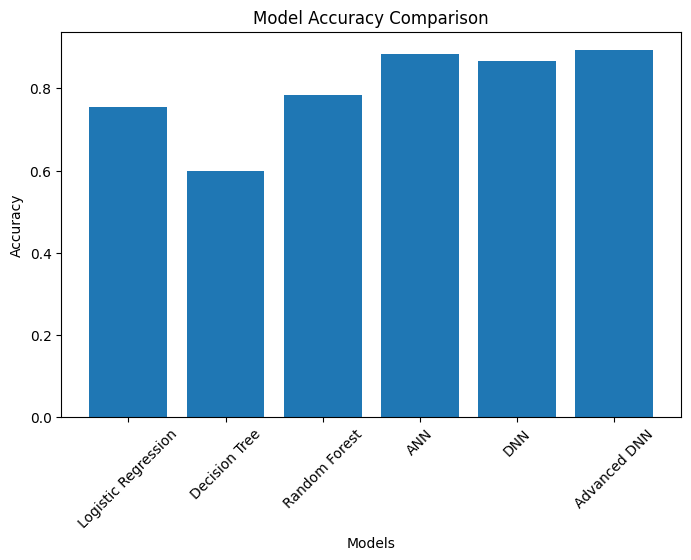

In [76]:
# ================================
#Graph for comparision of Models
# ================================
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "ANN",
    "DNN",
    "Advanced DNN"
]

accuracies = [
    lr_accuracy,
    dt_accuracy,
    rf_accuracy,
    ann_accuracy,
    dnn_accuracy,
    adv_dnn_accuracy
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.show()

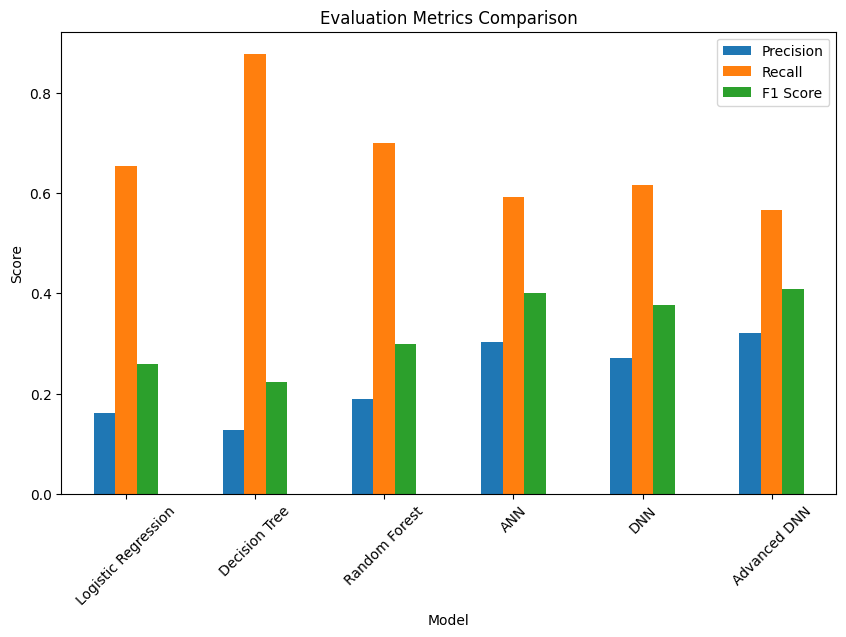

In [77]:
# ================================
#Evaluation metrics comparision
# ================================

metrics_table.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Evaluation Metrics Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

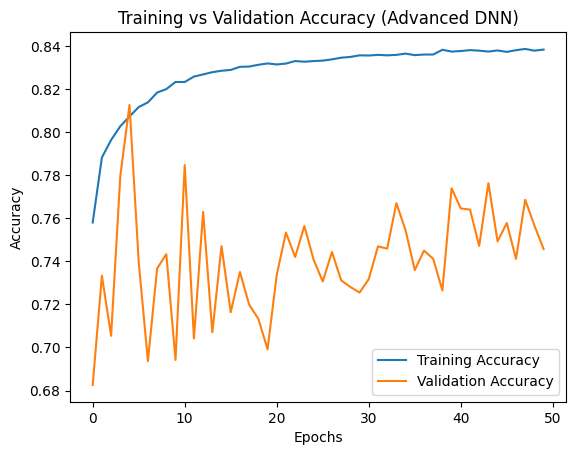

In [78]:
# ================================
#Training vs Validation Accuracy Graph
# ================================

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy (Advanced DNN)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 889us/step


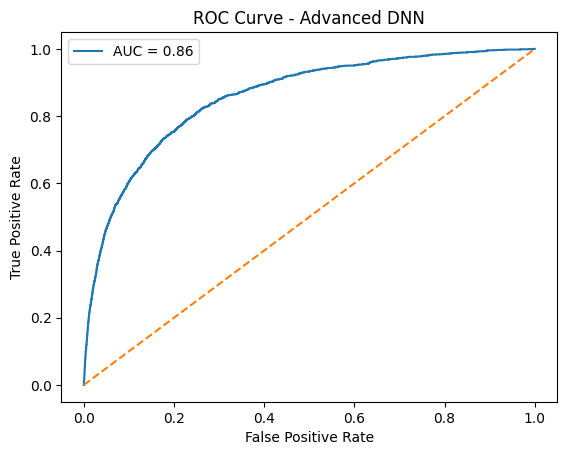

In [79]:
# ================================
#ROC Curve for best Model
# ================================

from sklearn.metrics import roc_curve, auc

y_pred_prob = adv_dnn_model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - Advanced DNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [80]:
# ================================
#Function for checking the customers
# ================================

import pandas as pd
def check_customer(customer):

    columns = [
        "RevolvingUtilizationOfUnsecuredLines",
        "age",
        "NumberOfTime30-59DaysPastDueNotWorse",
        "DebtRatio",
        "MonthlyIncome",
        "NumberOfOpenCreditLinesAndLoans",
        "NumberOfTimes90DaysLate",
        "NumberRealEstateLoansOrLines",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfDependents"
    ]

    df_test = pd.DataFrame(customer, columns=columns)

    # Create same engineered features
    df_test['income_debt_ratio'] = df_test['MonthlyIncome']/(df_test['DebtRatio']+1)

    df_test['credit_utilization'] = df_test['RevolvingUtilizationOfUnsecuredLines']/(df_test['NumberOfOpenCreditLinesAndLoans']+1)

    # Scaling
    scaled = scaler.transform(df_test)

    # Prediction
    prob = adv_dnn_model.predict(scaled)

    pred = (prob > 0.5).astype(int)

    print("Prediction Probability:", prob[0][0])

    if pred[0][0] == 0:
        print("Loan Status: Eligible (Low Risk)")
    else:
        print("Loan Status: Not Eligible (High Risk)")

In [81]:
customer_low = [[
    0.15,   # RevolvingUtilizationOfUnsecuredLines (low usage)
    48,     # age (stable age)
    0,      # no late payments
    0.25,   # low debt ratio
    60000,  # high income
    9,      # many credit lines (good history)
    0,      # no 90-day late
    2,      # some assets
    0,      # no delays
    1       # few dependents
]]

check_customer(customer_low)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediction Probability: 0.04490651
Loan Status: Eligible (Low Risk)


In [82]:
customer_high = [[
    0.95,   # very high credit usage
    29,
    6,      # many past dues
    1.40,   # very high debt ratio
    7000,   # low income
    3,
    5,      # frequent late payments
    0,
    3,
    4       # more dependents
]]

check_customer(customer_high)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction Probability: 0.92410934
Loan Status: Not Eligible (High Risk)


In [83]:
customer_mid = [[
    0.55,
    36,
    2,
    0.85,
    18000,
    5,
    1,
    1,
    1,
    3
]]

check_customer(customer_mid)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction Probability: 0.89468175
Loan Status: Not Eligible (High Risk)


In [84]:
customer_safe = [[
    0.10,   # minimal usage
    52,
    0,
    0.20,
    80000,  # very high income
    10,
    0,
    2,
    0,
    1
]]

check_customer(customer_safe)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction Probability: 0.04515264
Loan Status: Eligible (Low Risk)


In [85]:
customer_extreme = [[
    0.99,
    26,
    8,
    2.00,   # extreme debt
    5000,   # very low income
    2,
    6,
    0,
    4,
    5
]]

check_customer(customer_extreme)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediction Probability: 0.900751
Loan Status: Not Eligible (High Risk)


In [86]:
# model.save_weights("model.weights.h5")

In [87]:
# import joblib
# joblib.dump(scaler, "scaler.pkl")

In [88]:
# import os
# print(os.listdir())

In [89]:
# code = """
# import streamlit as st
# import pandas as pd
# import numpy as np
# from tensorflow.keras.models import load_model
# import joblib
# import matplotlib.pyplot as plt

# # Page config
# st.set_page_config(layout="wide")

# # =========================
# # LOAD MODEL & SCALER
# # =========================
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout

# # recreate model architecture SAME as training
# model = Sequential([
#     Dense(128, activation='relu', input_shape=(12,)),
#     Dropout(0.3),
#     Dense(64, activation='relu'),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])

# # load weights
# model.load_weights("model.weights.h5")
# scaler = joblib.load("scaler.pkl")

# # =========================
# # LOAD DATASET
# # =========================
# df = pd.read_csv("cs-training.csv")

# # Remove unwanted column
# df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# # =========================
# # FEATURE ENGINEERING
# # =========================
# df["credit_utilization"] = df["RevolvingUtilizationOfUnsecuredLines"] / (df["NumberOfOpenCreditLinesAndLoans"] + 1)
# df["income_debt_ratio"] = df["MonthlyIncome"] / (df["DebtRatio"] + 1)
# # =========================
# # PREDICTIONS
# # =========================
# X = df.drop("SeriousDlqin2yrs", axis=1)

# # correct column order
# X = X[scaler.feature_names_in_]

# X_scaled = scaler.transform(X)

# preds = model.predict(X_scaled)
# preds = (preds > 0.3).astype(int)

# df["Prediction"] = preds

# # =========================
# # TITLE
# # =========================
# st.markdown("<h1 style='text-align:center; color:#4CAF50;'>Loan Risk Dashboard</h1>", unsafe_allow_html=True)

# # =========================
# # KPI
# # =========================
# total = len(df)
# low = (preds == 0).sum()
# high = (preds == 1).sum()

# col1, col2, col3 = st.columns(3)

# col1.markdown(f"<h3>Total Applicants</h3><h2>{total}</h2>", unsafe_allow_html=True)
# col2.markdown(f"<h3 style='color:green;'>Low Risk</h3><h2>{(low/total)*100:.2f}%</h2>", unsafe_allow_html=True)
# col3.markdown(f"<h3 style='color:red;'>High Risk</h3><h2>{(high/total)*100:.2f}%</h2>", unsafe_allow_html=True)

# st.markdown("---")

# # =========================
# # CHARTS
# # =========================
# c1, c2 = st.columns(2)

# with c1:
#     st.subheader("Risk Distribution")
#     fig, ax = plt.subplots()
#     ax.pie([low, high], labels=["Low Risk", "High Risk"], autopct='%1.1f%%')
#     st.pyplot(fig)

# with c2:
#     st.subheader("Approval vs Rejection")
#     fig2, ax2 = plt.subplots()
#     ax2.bar(["Approved", "Rejected"], [low, high])
#     st.pyplot(fig2)

# st.markdown("---")

# left, right = st.columns([2,1])

# # =========================
# # MANAGER VIEW
# # =========================
# with left:
#     st.subheader("Manager View")

#     def color_pred(val):
#         return "color:red" if val == 1 else "color:green"

#     df["Risk"] = df["Prediction"].map({0: "Low Risk", 1: "High Risk"})
#     st.dataframe(df.head(200))
# # =========================
# # CUSTOMER CHECK
# # =========================
# with right:
#     st.subheader("Customer Risk Check")

#     income = st.number_input("Monthly Income", 0)
#     loan = st.number_input("Loan Amount", 0)
#     loans = st.number_input("Existing Loans", 0)

#     if st.button("Check Risk"):

#       # Step 1: Take base row
#       input_data = X.iloc[0].copy()

#       # Step 2: Replace user inputs
#       input_data["MonthlyIncome"] = income
#       input_data["DebtRatio"] = loan / (income + 1)
#       input_data["NumberOfOpenCreditLinesAndLoans"] = loans

#       # Step 3: CORRECT feature engineering
#       input_data["income_debt_ratio"] = input_data["MonthlyIncome"] / (input_data["DebtRatio"] + 1)

#       input_data["credit_utilization"] = (
#           input_data["RevolvingUtilizationOfUnsecuredLines"] /
#           (input_data["NumberOfOpenCreditLinesAndLoans"] + 1)
#       )

#       # Step 4: Convert to dataframe
#       input_df = pd.DataFrame([input_data])

#       # Step 5: Maintain column order
#       input_df = input_df[scaler.feature_names_in_]

#       # Step 6: Scale
#       input_scaled = scaler.transform(input_df)

#       # Step 7: Predict
#       prob = model.predict(input_scaled)[0][0]

#       # Step 8: Show score
#       st.write(f"Risk Score: {prob*100:.2f}%")

#       # Step 9: FINAL LOGIC (HYBRID)
#       if prob > 0.3 or loans > 8:
#           st.error("High Risk Customer")
#       else:
#           st.success("Low Risk Customer")
# """

# with open("app.py", "w") as f:
#     f.write(code)

# print("app.py created successfully")

In [90]:
# from google.colab import files
# files.download("app.py")

In [91]:
# from google.colab import files
# files.download("model.weights.h5")

In [92]:
# from google.colab import files
# files.download("model_new.keras")

In [93]:
# files.download("scaler.pkl")

In [94]:
# files.download("dataset.csv")

In [95]:
# from google.colab import files
# uploaded = files.upload()

In [96]:
# import numpy as np
# import pandas as pd
# import joblib

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from imblearn.over_sampling import SMOTE

# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout

# # Load dataset
# df = pd.read_csv("cs-training.csv")

# # Drop useless column
# df = df.drop(columns=["Unnamed: 0"])

# # Handle missing values
# df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
# df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

# # Feature engineering
# df['income_debt_ratio'] = df['MonthlyIncome'] / (df['DebtRatio'] + 1)
# df['credit_utilization'] = df['RevolvingUtilizationOfUnsecuredLines'] / (df['NumberOfOpenCreditLinesAndLoans'] + 1)

# # Split
# X = df.drop("SeriousDlqin2yrs", axis=1)
# y = df["SeriousDlqin2yrs"]

# # Scaling
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X_scaled, y, test_size=0.2, random_state=42
# )

# # Handle imbalance
# sm = SMOTE(random_state=42)
# X_train, y_train = sm.fit_resample(X_train, y_train)

# # Build DNN Model
# model = Sequential([
#     Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dropout(0.2),
#     Dense(1, activation='sigmoid')
# ])

# model.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

# # Train
# model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# # Save model & scaler
# model.save("model.h5")
# joblib.dump(scaler, "scaler.pkl")

# print("✅ Model and scaler saved successfully!")